# Clasificación del riesgo de diabetes mediante aprendizaje automático

## Evaluación final, calibración e interpretación

**Autor:** Alexander Marín  
**Área:** Analítica de datos aplicada al sector salud

### Objetivo

Evaluar el modelo seleccionado utilizando un conjunto de prueba reservado,
analizar la calibración de sus probabilidades, seleccionar un umbral de
clasificación con datos de entrenamiento e interpretar sus coeficientes.

El modelo seleccionado durante la validación cruzada fue una regresión logística
con:

- Imputación por mediana.
- Indicadores de ausencia.
- Estandarización.
- Regularización L1.
- `C = 0,1`.
- Pesos de clase balanceados.

El conjunto de prueba se utilizará una sola vez después de finalizar todas las
decisiones de calibración y selección del umbral.

Este ejercicio tiene fines educativos y no constituye una herramienta
diagnóstica ni una validación clínica.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_predict
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve
)

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    log_loss
)

pd.set_option(
    "display.max_columns",
    None
)

sns.set_theme(
    style="whitegrid",
    palette="deep"
)

RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5

In [2]:
DATA_PATH = "/content/1_diabetes.csv"

df = pd.read_csv(DATA_PATH)

invalid_zero_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

X = (
    df
    .drop(columns="Outcome")
    .copy()
)

y = (
    df["Outcome"]
    .copy()
)

X[invalid_zero_columns] = (
    X[invalid_zero_columns]
    .replace(0, np.nan)
)

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

print("\nDatos faltantes:")
print(X.isna().sum())

Dimensiones de X: (768, 8)
Dimensiones de y: (768,)

Datos faltantes:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

partition_verification = pd.DataFrame({
    "particion": [
        "Entrenamiento",
        "Prueba"
    ],
    "n_registros": [
        len(X_train),
        len(X_test)
    ],
    "n_positivos": [
        y_train.eq(1).sum(),
        y_test.eq(1).sum()
    ],
    "porcentaje_positivo": [
        y_train.mean() * 100,
        y_test.mean() * 100
    ]
})

partition_verification.round(2)

,particion,n_registros,n_positivos,porcentaje_positivo
0,Entrenamiento,614,214,34.85
1,Prueba,154,54,35.06


## Reconstrucción del modelo seleccionado

Se reproduce la misma partición utilizada durante la selección de modelos
mediante el mismo tamaño de prueba, semilla aleatoria y estratificación.

Esta reproducibilidad garantiza que el conjunto de prueba corresponde
exactamente a los 154 registros que permanecieron reservados durante el
desarrollo.

El preprocesamiento y el modelo se integran nuevamente en un pipeline. Las
medianas, indicadores y parámetros de escalado se aprenderán exclusivamente con
los datos utilizados para entrenar en cada momento.

In [4]:
selected_logistic_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        ),
        (
            "scaler",
            StandardScaler()
        ),
        (
            "model",
            LogisticRegression(
                C=0.1,
                penalty="l1",
                class_weight="balanced",
                solver="liblinear",
                max_iter=3000,
                random_state=RANDOM_STATE
            )
        )
    ]
)

outer_cross_validation = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE
)

## Predicciones fuera de pliegue

Para tomar decisiones sobre calibración y umbral se generan probabilidades fuera
de pliegue sobre el conjunto de entrenamiento.

Cada probabilidad se obtiene mediante un modelo que no utilizó ese registro
durante su ajuste. De esta forma se simula el comportamiento sobre observaciones
no vistas sin utilizar todavía el conjunto de prueba.

También se evalúa una calibración sigmoide. La calibración busca que una
probabilidad estimada, por ejemplo 0,70, corresponda aproximadamente a una
frecuencia observada del 70 %.

ROC-AUC y PR-AUC evalúan discriminación. Brier score y log loss evalúan la
calidad de las probabilidades; en estas dos últimas métricas, valores menores
indican mejor desempeño.

In [5]:
oof_probabilities_uncalibrated = cross_val_predict(
    estimator=selected_logistic_pipeline,
    X=X_train,
    y=y_train,
    cv=outer_cross_validation,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print(
    "Probabilidades fuera de pliegue obtenidas:",
    len(oof_probabilities_uncalibrated)
)

Probabilidades fuera de pliegue obtenidas: 614


In [6]:
calibrated_logistic_model = CalibratedClassifierCV(
    estimator=selected_logistic_pipeline,
    method="sigmoid",
    cv=5,
    ensemble=False,
    n_jobs=1
)

oof_probabilities_calibrated = cross_val_predict(
    estimator=calibrated_logistic_model,
    X=X_train,
    y=y_train,
    cv=outer_cross_validation,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

print(
    "Probabilidades calibradas fuera de pliegue obtenidas:",
    len(oof_probabilities_calibrated)
)

Probabilidades calibradas fuera de pliegue obtenidas: 614


In [7]:
calibration_comparison = pd.DataFrame({
    "modelo": [
        "Sin calibración",
        "Calibración sigmoide"
    ],

    "roc_auc": [
        roc_auc_score(
            y_train,
            oof_probabilities_uncalibrated
        ),
        roc_auc_score(
            y_train,
            oof_probabilities_calibrated
        )
    ],

    "pr_auc": [
        average_precision_score(
            y_train,
            oof_probabilities_uncalibrated
        ),
        average_precision_score(
            y_train,
            oof_probabilities_calibrated
        )
    ],

    "brier_score": [
        brier_score_loss(
            y_train,
            oof_probabilities_uncalibrated
        ),
        brier_score_loss(
            y_train,
            oof_probabilities_calibrated
        )
    ],

    "log_loss": [
        log_loss(
            y_train,
            oof_probabilities_uncalibrated
        ),
        log_loss(
            y_train,
            oof_probabilities_calibrated
        )
    ]
})

calibration_comparison = (
    calibration_comparison
    .set_index("modelo")
    .round(4)
)

calibration_comparison

,roc_auc,pr_auc,brier_score,log_loss
modelo,,,,
Sin calibración,0.8446,0.7282,0.1653,0.5063
Calibración sigmoide,0.8444,0.7279,0.1497,0.4620


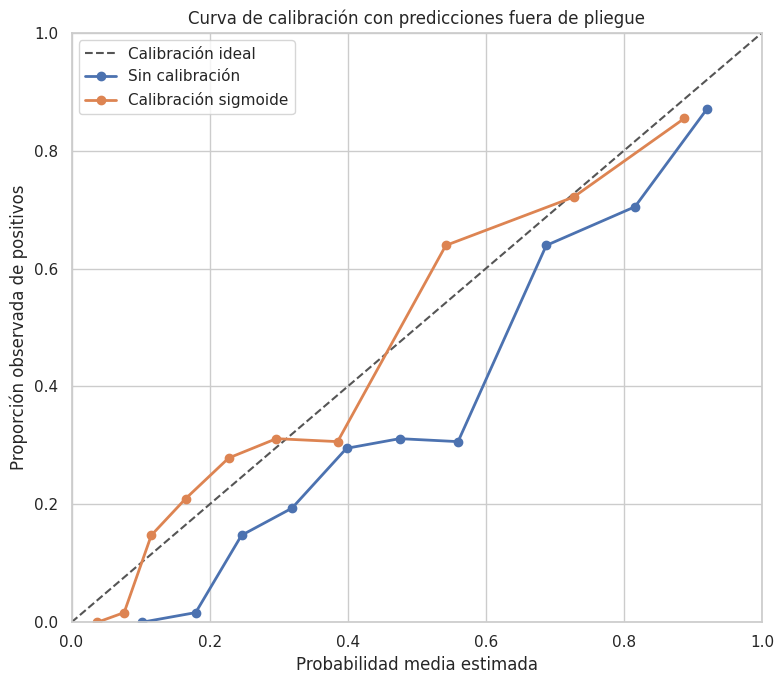

In [8]:
fraction_positive_uncalibrated, mean_predicted_uncalibrated = (
    calibration_curve(
        y_train,
        oof_probabilities_uncalibrated,
        n_bins=10,
        strategy="quantile"
    )
)

fraction_positive_calibrated, mean_predicted_calibrated = (
    calibration_curve(
        y_train,
        oof_probabilities_calibrated,
        n_bins=10,
        strategy="quantile"
    )
)

fig, ax = plt.subplots(
    figsize=(8, 7)
)

ax.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#555555",
    label="Calibración ideal"
)

ax.plot(
    mean_predicted_uncalibrated,
    fraction_positive_uncalibrated,
    marker="o",
    linewidth=2,
    label="Sin calibración"
)

ax.plot(
    mean_predicted_calibrated,
    fraction_positive_calibrated,
    marker="o",
    linewidth=2,
    label="Calibración sigmoide"
)

ax.set_title(
    "Curva de calibración con predicciones fuera de pliegue"
)

ax.set_xlabel(
    "Probabilidad media estimada"
)

ax.set_ylabel(
    "Proporción observada de positivos"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()

### Interpretación de la calibración

La calibración sigmoide mantuvo prácticamente intacta la capacidad de
discriminación:

- ROC-AUC: 0,8446 sin calibrar y 0,8444 calibrado.
- PR-AUC: 0,7282 sin calibrar y 0,7279 calibrado.

En cambio, mejoró las métricas específicas de probabilidad:

- Brier score: disminuyó de 0,1653 a 0,1497.
- Log loss: disminuyó de 0,5063 a 0,4620.

Estos resultados indican que la calibración no modificó sustancialmente el orden
de riesgo asignado a los registros, pero produjo probabilidades más coherentes
con las frecuencias observadas.

Por esta razón, se conserva la calibración sigmoide para la evaluación final y
la selección del umbral.

La curva debe interpretarse con cautela porque se construyó con 614 registros y
diez grupos de tamaño similar. Las variaciones entre puntos pueden reflejar tanto
descalibración como variabilidad muestral.

## Selección del umbral de clasificación

La probabilidad debe convertirse en una clasificación negativa o positiva
mediante un umbral.

El valor 0,50 es convencional, pero no necesariamente ofrece el mejor equilibrio
entre falsos positivos y falsos negativos.

Se evaluarán cuatro alternativas utilizando exclusivamente probabilidades fuera
de pliegue del entrenamiento:

1. Umbral convencional de 0,50.
2. Máximo índice de Youden: sensibilidad + especificidad − 1.
3. Máximo F1.
4. Mayor especificidad posible manteniendo al menos 80 % de sensibilidad.

Debido a que no se dispone de costos clínicos definidos para los errores, el
índice de Youden se utilizará como criterio principal. El escenario con
sensibilidad mínima del 80 % se presentará como análisis alternativo orientado a
tamizaje.

In [9]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [10]:
threshold_grid = np.arange(
    0.01,
    1.00,
    0.01
)

threshold_results = []

for threshold in threshold_grid:

    predicted_class = (
        oof_probabilities_calibrated
        >= threshold
    ).astype(int)

    true_negative, false_positive, false_negative, true_positive = (
        confusion_matrix(
            y_train,
            predicted_class,
            labels=[0, 1]
        )
        .ravel()
    )

    sensitivity = (
        true_positive
        / (true_positive + false_negative)
    )

    specificity = (
        true_negative
        / (true_negative + false_positive)
    )

    precision = precision_score(
        y_train,
        predicted_class,
        zero_division=0
    )

    f1 = f1_score(
        y_train,
        predicted_class,
        zero_division=0
    )

    accuracy = accuracy_score(
        y_train,
        predicted_class
    )

    threshold_results.append({
        "threshold": threshold,
        "accuracy": accuracy,
        "precision": precision,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "f1": f1,
        "youden_index": (
            sensitivity
            + specificity
            - 1
        ),
        "true_negative": true_negative,
        "false_positive": false_positive,
        "false_negative": false_negative,
        "true_positive": true_positive
    })

threshold_results = pd.DataFrame(
    threshold_results
)

threshold_results.head()

,threshold,accuracy,precision,sensitivity,specificity,f1,youden_index,true_negative,false_positive,false_negative,true_positive
0,0.01,0.351792,0.349673,1.0,0.0050,0.518160,0.0050,2,398,0,214
1,0.02,0.358306,0.351974,1.0,0.0150,0.520681,0.0150,6,394,0,214
2,0.03,0.371336,0.356667,1.0,0.0350,0.525799,0.0350,14,386,0,214
3,0.04,0.402280,0.368330,1.0,0.0825,0.538365,0.0825,33,367,0,214
4,0.05,0.431596,0.380107,1.0,0.1275,0.550837,0.1275,51,349,0,214


In [11]:
default_threshold_result = (
    threshold_results
    .iloc[
        (
            threshold_results["threshold"]
            - 0.50
        )
        .abs()
        .argsort()[:1]
    ]
    .iloc[0]
)

youden_threshold_result = (
    threshold_results
    .loc[
        threshold_results[
            "youden_index"
        ].idxmax()
    ]
)

f1_threshold_result = (
    threshold_results
    .loc[
        threshold_results[
            "f1"
        ].idxmax()
    ]
)

sensitivity_target_candidates = (
    threshold_results[
        threshold_results["sensitivity"]
        >= 0.80
    ]
)

sensitivity_target_result = (
    sensitivity_target_candidates
    .sort_values(
        [
            "specificity",
            "threshold"
        ],
        ascending=[
            False,
            False
        ]
    )
    .iloc[0]
)

threshold_comparison = pd.DataFrame(
    {
        "Umbral 0,50": default_threshold_result,
        "Máximo Youden": youden_threshold_result,
        "Máximo F1": f1_threshold_result,
        "Sensibilidad ≥ 0,80": sensitivity_target_result
    }
).T

threshold_comparison = (
    threshold_comparison[
        [
            "threshold",
            "accuracy",
            "precision",
            "sensitivity",
            "specificity",
            "f1",
            "youden_index",
            "false_positive",
            "false_negative"
        ]
    ]
    .round(3)
)

threshold_comparison

,threshold,accuracy,precision,sensitivity,specificity,f1,youden_index,false_positive,false_negative
"Umbral 0,50",0.50,0.792,0.756,0.593,0.898,0.665,0.491,41.0,87.0
Máximo Youden,0.45,0.793,0.730,0.645,0.872,0.685,0.517,51.0,76.0
Máximo F1,0.45,0.793,0.730,0.645,0.872,0.685,0.517,51.0,76.0
"Sensibilidad ≥ 0,80",0.27,0.733,0.584,0.813,0.690,0.680,0.503,124.0,40.0


In [12]:
selected_threshold = float(
    youden_threshold_result[
        "threshold"
    ]
)

sensitivity_oriented_threshold = float(
    sensitivity_target_result[
        "threshold"
    ]
)

print(
    "Umbral principal seleccionado:",
    round(selected_threshold, 2)
)

print(
    "Umbral alternativo orientado a sensibilidad:",
    round(sensitivity_oriented_threshold, 2)
)

Umbral principal seleccionado: 0.45
Umbral alternativo orientado a sensibilidad: 0.27


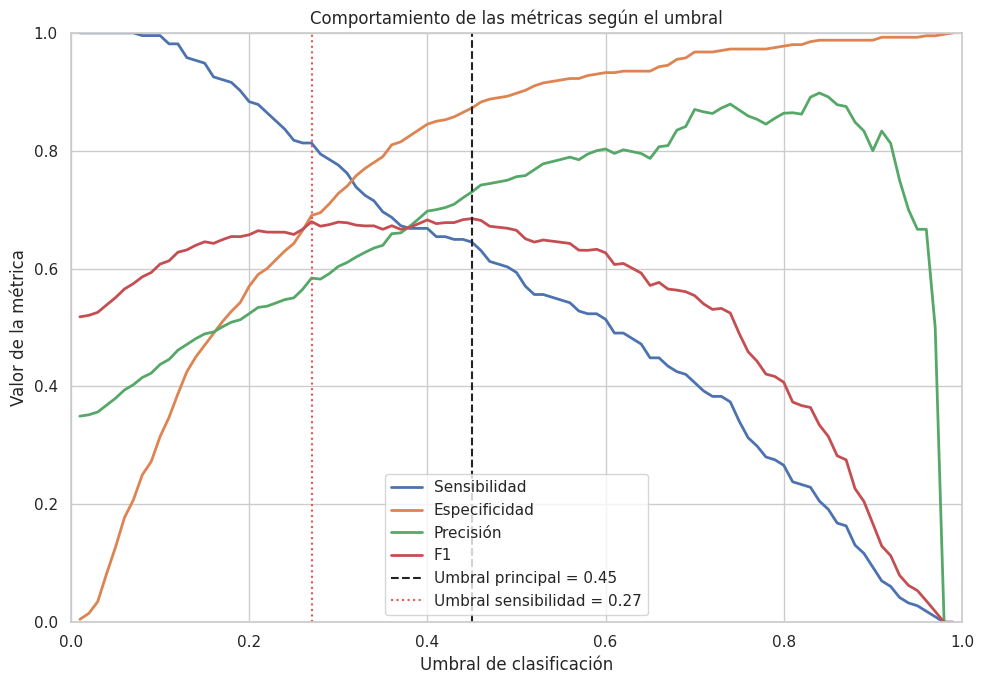

In [13]:
fig, ax = plt.subplots(
    figsize=(10, 7)
)

ax.plot(
    threshold_results["threshold"],
    threshold_results["sensitivity"],
    label="Sensibilidad",
    linewidth=2
)

ax.plot(
    threshold_results["threshold"],
    threshold_results["specificity"],
    label="Especificidad",
    linewidth=2
)

ax.plot(
    threshold_results["threshold"],
    threshold_results["precision"],
    label="Precisión",
    linewidth=2
)

ax.plot(
    threshold_results["threshold"],
    threshold_results["f1"],
    label="F1",
    linewidth=2
)

ax.axvline(
    selected_threshold,
    color="#222222",
    linestyle="--",
    label=(
        f"Umbral principal = "
        f"{selected_threshold:.2f}"
    )
)

ax.axvline(
    sensitivity_oriented_threshold,
    color="#E45756",
    linestyle=":",
    label=(
        f"Umbral sensibilidad = "
        f"{sensitivity_oriented_threshold:.2f}"
    )
)

ax.set_title(
    "Comportamiento de las métricas según el umbral"
)

ax.set_xlabel(
    "Umbral de clasificación"
)

ax.set_ylabel(
    "Valor de la métrica"
)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.legend()

plt.tight_layout()
plt.show()

### Interpretación de los umbrales

El umbral convencional de 0,50 alcanzó una sensibilidad de 0,593 y una
especificidad de 0,898.

El umbral 0,45 maximizó simultáneamente el índice de Youden y el F1:

- Sensibilidad: 0,645.
- Especificidad: 0,872.
- Precisión: 0,730.
- F1: 0,685.

Frente al umbral convencional, permitió identificar 11 resultados positivos
adicionales, a costa de generar 10 falsos positivos adicionales.

El umbral 0,27 alcanzó una sensibilidad de 0,813, pero redujo la especificidad a
0,690 y produjo 124 falsos positivos durante la validación fuera de pliegue.

Se selecciona 0,45 como umbral principal porque ofrece el mejor equilibrio entre
sensibilidad y especificidad en ausencia de costos clínicos definidos.

El umbral 0,27 se conserva como escenario alternativo orientado a sensibilidad.
No se interpreta como un punto de corte clínicamente validado.

## Evaluación final en el conjunto de prueba

Todas las decisiones de modelo, calibración y umbral fueron tomadas utilizando
exclusivamente el conjunto de entrenamiento.

A continuación, el modelo calibrado se ajusta con los 614 registros de
entrenamiento y se evalúa una única vez sobre los 154 registros reservados.

Se reportan tres umbrales definidos previamente:

- 0,50 como referencia convencional.
- 0,45 como umbral principal.
- 0,27 como escenario alternativo orientado a sensibilidad.

Los resultados de prueba no se utilizarán para modificar ninguno de estos
umbrales.

In [14]:
final_calibrated_model = CalibratedClassifierCV(
    estimator=selected_logistic_pipeline,
    method="sigmoid",
    cv=5,
    ensemble=False,
    n_jobs=-1
)

final_calibrated_model.fit(
    X_train,
    y_train
)

test_probabilities = (
    final_calibrated_model
    .predict_proba(X_test)[:, 1]
)

print(
    "Probabilidades generadas para prueba:",
    len(test_probabilities)
)

Probabilidades generadas para prueba: 154


In [15]:
test_probability_metrics = pd.DataFrame({
    "roc_auc": [
        roc_auc_score(
            y_test,
            test_probabilities
        )
    ],

    "pr_auc": [
        average_precision_score(
            y_test,
            test_probabilities
        )
    ],

    "brier_score": [
        brier_score_loss(
            y_test,
            test_probabilities
        )
    ],

    "log_loss": [
        log_loss(
            y_test,
            test_probabilities
        )
    ]
})

test_probability_metrics = (
    test_probability_metrics
    .rename(
        index={
            0: "Conjunto de prueba"
        }
    )
    .round(4)
)

test_probability_metrics

,roc_auc,pr_auc,brier_score,log_loss
Conjunto de prueba,0.8115,0.6714,0.1747,0.5152


In [16]:
test_thresholds = {
    "Umbral convencional 0,50": 0.50,
    "Umbral principal 0,45": selected_threshold,
    "Sensibilidad ≥ 0,80": sensitivity_oriented_threshold
}

test_threshold_results = []

for threshold_name, threshold_value in test_thresholds.items():

    test_predictions = (
        test_probabilities
        >= threshold_value
    ).astype(int)

    true_negative, false_positive, false_negative, true_positive = (
        confusion_matrix(
            y_test,
            test_predictions,
            labels=[0, 1]
        )
        .ravel()
    )

    sensitivity = (
        true_positive
        / (true_positive + false_negative)
    )

    specificity = (
        true_negative
        / (true_negative + false_positive)
    )

    precision = precision_score(
        y_test,
        test_predictions,
        zero_division=0
    )

    negative_predictive_value = (
        true_negative
        / (true_negative + false_negative)
        if (true_negative + false_negative) > 0
        else 0
    )

    test_threshold_results.append({
        "escenario": threshold_name,
        "threshold": threshold_value,
        "accuracy": accuracy_score(
            y_test,
            test_predictions
        ),
        "precision": precision,
        "negative_predictive_value": negative_predictive_value,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "f1": f1_score(
            y_test,
            test_predictions,
            zero_division=0
        ),
        "true_negative": true_negative,
        "false_positive": false_positive,
        "false_negative": false_negative,
        "true_positive": true_positive
    })

test_threshold_results = (
    pd.DataFrame(test_threshold_results)
    .set_index("escenario")
    .round(3)
)

test_threshold_results

,threshold,accuracy,precision,negative_predictive_value,sensitivity,specificity,f1,true_negative,false_positive,false_negative,true_positive
escenario,,,,,,,,,,,
"Umbral convencional 0,50",0.50,0.701,0.587,0.750,0.500,0.81,0.540,81,19,27,27
"Umbral principal 0,45",0.45,0.708,0.588,0.767,0.556,0.79,0.571,79,21,24,30
"Sensibilidad ≥ 0,80",0.27,0.734,0.582,0.893,0.852,0.67,0.692,67,33,8,46


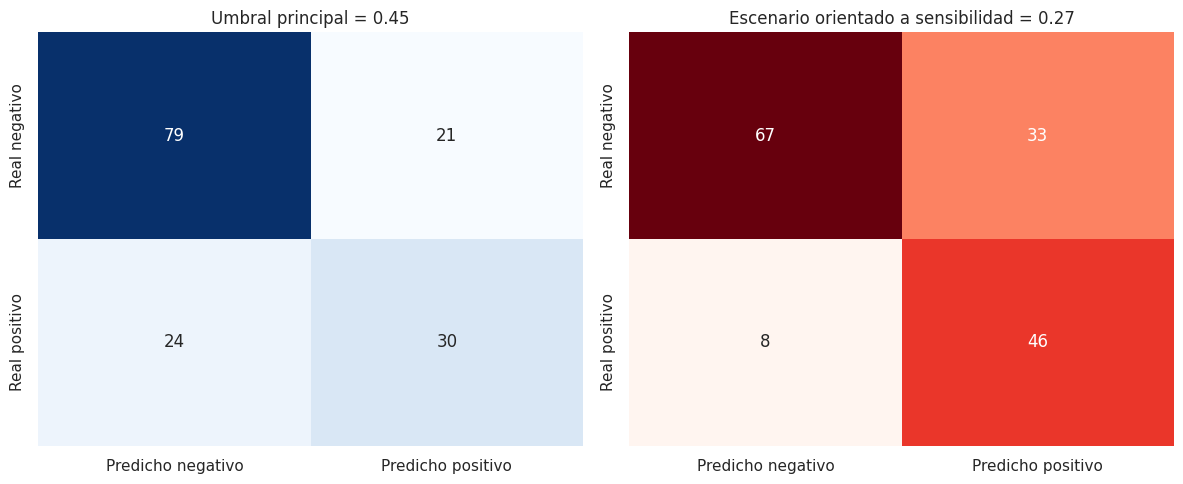

In [17]:
primary_test_predictions = (
    test_probabilities
    >= selected_threshold
).astype(int)

sensitivity_test_predictions = (
    test_probabilities
    >= sensitivity_oriented_threshold
).astype(int)

primary_confusion_matrix = confusion_matrix(
    y_test,
    primary_test_predictions,
    labels=[0, 1]
)

sensitivity_confusion_matrix = confusion_matrix(
    y_test,
    sensitivity_test_predictions,
    labels=[0, 1]
)

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(12, 5)
)

sns.heatmap(
    primary_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=[
        "Predicho negativo",
        "Predicho positivo"
    ],
    yticklabels=[
        "Real negativo",
        "Real positivo"
    ],
    ax=axes[0]
)

axes[0].set_title(
    f"Umbral principal = {selected_threshold:.2f}"
)

axes[0].set_xlabel("")
axes[0].set_ylabel("")

sns.heatmap(
    sensitivity_confusion_matrix,
    annot=True,
    fmt="d",
    cmap="Reds",
    cbar=False,
    xticklabels=[
        "Predicho negativo",
        "Predicho positivo"
    ],
    yticklabels=[
        "Real negativo",
        "Real positivo"
    ],
    ax=axes[1]
)

axes[1].set_title(
    "Escenario orientado a sensibilidad "
    f"= {sensitivity_oriented_threshold:.2f}"
)

axes[1].set_xlabel("")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Interpretación de la evaluación final

El modelo alcanzó un ROC-AUC de 0,812 y un PR-AUC de 0,671 en el conjunto de
prueba. Ambas métricas fueron inferiores a las obtenidas mediante predicciones
fuera de pliegue, lo que evidencia una reducción moderada del desempeño sobre
datos completamente reservados.

El Brier score aumentó de 0,150 a 0,175 y el log loss de 0,462 a 0,515. Esto
indica que las probabilidades fueron menos precisas en prueba, aunque conservaron
una capacidad de discriminación útil para un ejercicio educativo.

Con el umbral principal de 0,45, el modelo identificó 30 de los 54 resultados
positivos y clasificó correctamente 79 de los 100 negativos:

- Sensibilidad: 0,556.
- Especificidad: 0,790.
- Precisión: 0,588.
- F1: 0,571.
- Falsos negativos: 24.
- Falsos positivos: 21.

El escenario alternativo con umbral 0,27 identificó 46 de los 54 resultados
positivos:

- Sensibilidad: 0,852.
- Especificidad: 0,670.
- Precisión: 0,582.
- F1: 0,692.
- Falsos negativos: 8.
- Falsos positivos: 33.

El umbral orientado a sensibilidad redujo los falsos negativos de 24 a 8, a
costa de aumentar los falsos positivos de 21 a 33.

Aunque el umbral 0,27 obtuvo mejores resultados en varias métricas de prueba, no
se selecciona retrospectivamente como nuevo umbral principal. Ambos escenarios
fueron definidos antes de utilizar la prueba y se reportan según objetivos
diferentes.

Estos resultados no establecen utilidad clínica. La elección real de un umbral
requeriría definir los costos de falsos positivos y falsos negativos y realizar
validación externa.

In [18]:
from sklearn.metrics import (
    roc_curve,
    precision_recall_curve
)

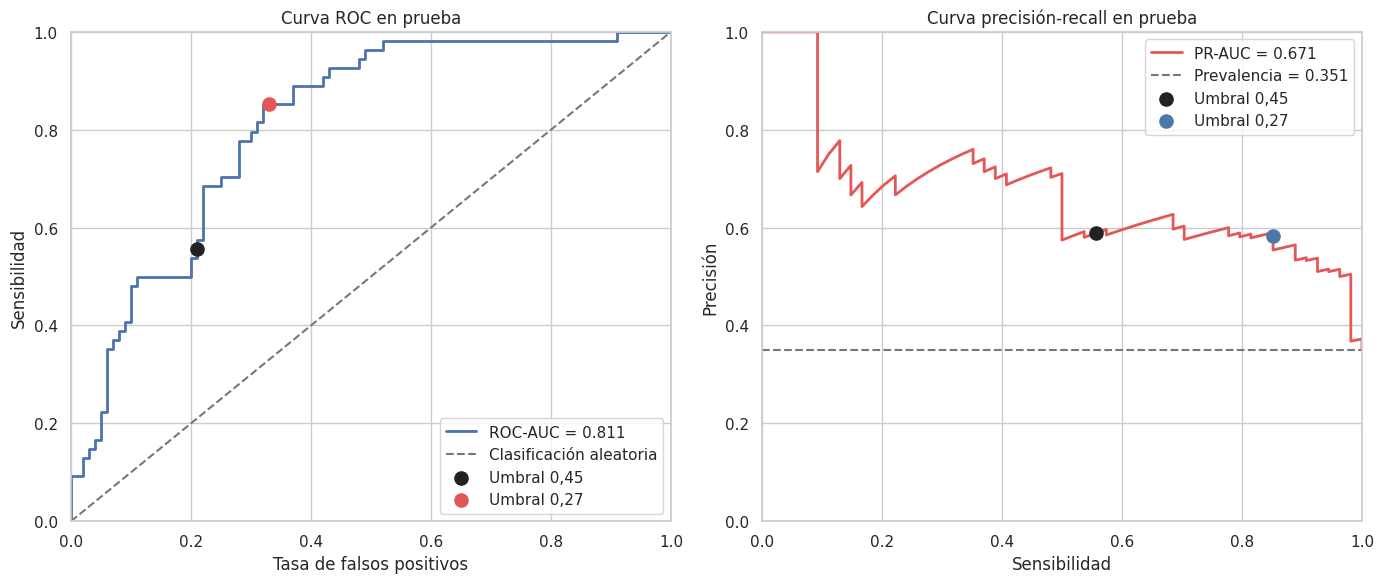

In [19]:
false_positive_rate, true_positive_rate, roc_thresholds = (
    roc_curve(
        y_test,
        test_probabilities
    )
)

precision_curve, recall_curve, pr_thresholds = (
    precision_recall_curve(
        y_test,
        test_probabilities
    )
)

test_roc_auc = roc_auc_score(
    y_test,
    test_probabilities
)

test_pr_auc = average_precision_score(
    y_test,
    test_probabilities
)

test_prevalence = y_test.mean()

primary_result = test_threshold_results.loc[
    "Umbral principal 0,45"
]

sensitivity_result = test_threshold_results.loc[
    "Sensibilidad ≥ 0,80"
]

fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 6)
)

# Curva ROC
axes[0].plot(
    false_positive_rate,
    true_positive_rate,
    linewidth=2,
    label=f"ROC-AUC = {test_roc_auc:.3f}"
)

axes[0].plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="#777777",
    label="Clasificación aleatoria"
)

axes[0].scatter(
    1 - primary_result["specificity"],
    primary_result["sensitivity"],
    s=90,
    color="#222222",
    label="Umbral 0,45",
    zorder=3
)

axes[0].scatter(
    1 - sensitivity_result["specificity"],
    sensitivity_result["sensitivity"],
    s=90,
    color="#E45756",
    label="Umbral 0,27",
    zorder=3
)

axes[0].set_title("Curva ROC en prueba")
axes[0].set_xlabel("Tasa de falsos positivos")
axes[0].set_ylabel("Sensibilidad")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend()

# Curva precisión-recall
axes[1].plot(
    recall_curve,
    precision_curve,
    linewidth=2,
    color="#E45756",
    label=f"PR-AUC = {test_pr_auc:.3f}"
)

axes[1].axhline(
    test_prevalence,
    linestyle="--",
    color="#777777",
    label=f"Prevalencia = {test_prevalence:.3f}"
)

axes[1].scatter(
    primary_result["sensitivity"],
    primary_result["precision"],
    s=90,
    color="#222222",
    label="Umbral 0,45",
    zorder=3
)

axes[1].scatter(
    sensitivity_result["sensitivity"],
    sensitivity_result["precision"],
    s=90,
    color="#4C78A8",
    label="Umbral 0,27",
    zorder=3
)

axes[1].set_title("Curva precisión-recall en prueba")
axes[1].set_xlabel("Sensibilidad")
axes[1].set_ylabel("Precisión")
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretación de las curvas ROC y precisión-recall

La curva ROC se mantiene por encima de la diagonal de clasificación aleatoria y
alcanza un ROC-AUC de 0,811. Esto indica que el modelo conserva una capacidad
moderada para asignar probabilidades mayores a los registros positivos que a los
negativos.

La curva precisión-recall alcanza un PR-AUC de 0,671, superior a la prevalencia
positiva de 0,351 utilizada como referencia mínima.

El umbral principal de 0,45 se ubica en una región con menor tasa de falsos
positivos, pero también menor sensibilidad.

El umbral 0,27 aumenta considerablemente la sensibilidad, desplazándose hacia
una tasa mayor de falsos positivos. A pesar de este desplazamiento, la precisión
se mantiene muy próxima a la obtenida con el umbral principal.

Las curvas evalúan el desempeño sobre diferentes umbrales, mientras que los
puntos destacados representan dos decisiones operativas definidas antes de
examinar el conjunto de prueba.

## Incertidumbre de las métricas

El conjunto de prueba contiene únicamente 154 registros. Por tanto, las métricas
puntuales pueden cambiar ante variaciones en la muestra.

Se utiliza bootstrap estratificado con 2000 repeticiones para estimar intervalos
percentiles del 95 %. En cada repetición se remuestrean por separado los
registros positivos y negativos, conservando la cantidad de observaciones de
cada clase.

Los intervalos describen incertidumbre muestral interna y no sustituyen una
validación externa.

In [20]:
def calculate_classification_metrics(
    y_true,
    probabilities,
    threshold
):
    predictions = (
        probabilities
        >= threshold
    ).astype(int)

    true_negative, false_positive, false_negative, true_positive = (
        confusion_matrix(
            y_true,
            predictions,
            labels=[0, 1]
        )
        .ravel()
    )

    sensitivity = (
        true_positive
        / (true_positive + false_negative)
    )

    specificity = (
        true_negative
        / (true_negative + false_positive)
    )

    return {
        "accuracy": accuracy_score(
            y_true,
            predictions
        ),

        "precision": precision_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "sensitivity": sensitivity,

        "specificity": specificity,

        "f1": f1_score(
            y_true,
            predictions,
            zero_division=0
        ),

        "roc_auc": roc_auc_score(
            y_true,
            probabilities
        ),

        "pr_auc": average_precision_score(
            y_true,
            probabilities
        ),

        "brier_score": brier_score_loss(
            y_true,
            probabilities
        ),

        "log_loss": log_loss(
            y_true,
            probabilities
        )
    }

In [21]:
def stratified_bootstrap(
    y_true,
    probabilities,
    threshold,
    n_iterations=2000,
    random_state=RANDOM_STATE
):
    y_array = np.asarray(y_true)
    probability_array = np.asarray(
        probabilities
    )

    negative_indices = np.flatnonzero(
        y_array == 0
    )

    positive_indices = np.flatnonzero(
        y_array == 1
    )

    random_generator = np.random.default_rng(
        random_state
    )

    bootstrap_results = []

    for iteration in range(n_iterations):

        sampled_negative_indices = (
            random_generator.choice(
                negative_indices,
                size=len(negative_indices),
                replace=True
            )
        )

        sampled_positive_indices = (
            random_generator.choice(
                positive_indices,
                size=len(positive_indices),
                replace=True
            )
        )

        sampled_indices = np.concatenate(
            [
                sampled_negative_indices,
                sampled_positive_indices
            ]
        )

        sampled_metrics = (
            calculate_classification_metrics(
                y_true=y_array[sampled_indices],
                probabilities=probability_array[
                    sampled_indices
                ],
                threshold=threshold
            )
        )

        bootstrap_results.append(
            sampled_metrics
        )

    return pd.DataFrame(
        bootstrap_results
    )

In [22]:
primary_bootstrap_results = stratified_bootstrap(
    y_true=y_test,
    probabilities=test_probabilities,
    threshold=selected_threshold,
    n_iterations=2000,
    random_state=RANDOM_STATE
)

sensitivity_bootstrap_results = stratified_bootstrap(
    y_true=y_test,
    probabilities=test_probabilities,
    threshold=sensitivity_oriented_threshold,
    n_iterations=2000,
    random_state=RANDOM_STATE + 1
)

In [23]:
def summarize_bootstrap_results(
    bootstrap_results,
    point_estimates
):
    confidence_intervals = (
        bootstrap_results
        .quantile(
            [
                0.025,
                0.975
            ]
        )
        .T
    )

    confidence_intervals.columns = [
        "ci_95_lower",
        "ci_95_upper"
    ]

    confidence_intervals.insert(
        0,
        "estimate",
        pd.Series(point_estimates)
    )

    return confidence_intervals


primary_point_estimates = (
    calculate_classification_metrics(
        y_true=y_test,
        probabilities=test_probabilities,
        threshold=selected_threshold
    )
)

sensitivity_point_estimates = (
    calculate_classification_metrics(
        y_true=y_test,
        probabilities=test_probabilities,
        threshold=sensitivity_oriented_threshold
    )
)

primary_bootstrap_summary = (
    summarize_bootstrap_results(
        bootstrap_results=primary_bootstrap_results,
        point_estimates=primary_point_estimates
    )
)

sensitivity_bootstrap_summary = (
    summarize_bootstrap_results(
        bootstrap_results=sensitivity_bootstrap_results,
        point_estimates=sensitivity_point_estimates
    )
)

bootstrap_summary = pd.concat(
    {
        "Umbral principal 0,45": (
            primary_bootstrap_summary
        ),

        "Sensibilidad ≥ 0,80": (
            sensitivity_bootstrap_summary
        )
    },
    names=[
        "escenario",
        "metrica"
    ]
)

bootstrap_summary.round(3)

estimate  ci_95_lower  ci_95_upper
escenario             metrica                                        
Umbral principal 0,45 accuracy        0.708        0.636        0.779
                      precision       0.588        0.475        0.702
                      sensitivity     0.556        0.407        0.685
                      specificity     0.790        0.710        0.870
                      f1              0.571        0.452        0.678
                      roc_auc         0.811        0.737        0.876
                      pr_auc          0.671        0.572        0.790
                      brier_score     0.175        0.140        0.211
                      log_loss        0.515        0.429        0.609
Sensibilidad ≥ 0,80   accuracy        0.734        0.669        0.799
                      precision       0.582        0.516        0.662
                      sensitivity     0.852        0.759        0.944
                      specificity     0.670        0.580        0.760
                      f1              0.692        0.625        0.760
                      roc_auc         0.811        0.743        0.878
                      pr_auc          0.671        0.572        0.781
                      brier_score     0.175        0.140        0.210
                      log_loss        0.515        0.427        0.605

### Interpretación de la incertidumbre

Los intervalos de confianza muestran que las métricas obtenidas en el conjunto de prueba están sujetas a una variabilidad importante, debido principalmente a su tamaño reducido de 154 observaciones.

Con el umbral principal de 0,45, la sensibilidad estimada fue de 0,556, con un intervalo de confianza del 95 % aproximadamente entre 0,407 y 0,685. Esto indica que la capacidad del modelo para identificar casos positivos podría variar de manera considerable en otras muestras de la misma población.

El escenario orientado a sensibilidad alcanzó una sensibilidad de 0,852, con un intervalo aproximado entre 0,759 y 0,944. Aunque este resultado es más favorable para reducir falsos negativos, se obtiene a costa de una menor especificidad, estimada en 0,670.

El ROC-AUC presentó un intervalo aproximado entre 0,74 y 0,88, compatible con una capacidad de discriminación moderada, pero todavía incierta. En consecuencia, los resultados deben entenderse como estimaciones propias de un ejercicio educativo y no como evidencia suficiente para implementar el modelo en un entorno clínico.

## Interpretación de las variables del modelo

Para examinar cómo la regresión logística construye sus predicciones, se ajusta nuevamente el pipeline seleccionado utilizando todo el conjunto de entrenamiento.

Los coeficientes se calculan después de la imputación y estandarización de las variables. Por ello, su magnitud permite comparar la influencia relativa de las características dentro del modelo:

- Un coeficiente positivo aumenta la probabilidad estimada de pertenecer a la clase positiva.
- Un coeficiente negativo disminuye esa probabilidad.
- Un coeficiente igual a cero indica que la regularización L1 excluyó esa característica del modelo.

Estos coeficientes describen asociaciones utilizadas para la predicción y no deben interpretarse como relaciones causales ni como efectos clínicos independientes.

In [24]:
from sklearn.base import clone

interpretation_pipeline = clone(
    selected_logistic_pipeline
)

interpretation_pipeline.fit(
    X_train,
    y_train
)

fitted_imputer = interpretation_pipeline.named_steps[
    "imputer"
]

fitted_logistic_model = interpretation_pipeline.named_steps[
    "model"
]

transformed_feature_names = (
    fitted_imputer.get_feature_names_out(
        X_train.columns
    )
)

coefficient_results = pd.DataFrame({
    "variable": transformed_feature_names,
    "coeficiente_estandarizado": (
        fitted_logistic_model.coef_[0]
    )
})

coefficient_results["magnitud_absoluta"] = (
    coefficient_results[
        "coeficiente_estandarizado"
    ].abs()
)

coefficient_results["direccion"] = np.select(
    [
        coefficient_results[
            "coeficiente_estandarizado"
        ] > 0,
        coefficient_results[
            "coeficiente_estandarizado"
        ] < 0
    ],
    [
        "Asociación positiva",
        "Asociación negativa"
    ],
    default="Excluida por L1"
)

coefficient_results = coefficient_results.sort_values(
    "magnitud_absoluta",
    ascending=False
).reset_index(drop=True)

coefficient_results.round(4)

,variable,coeficiente_estandarizado,magnitud_absoluta,direccion
0,Glucose,1.0453,1.0453,Asociación positiva
1,BMI,0.5773,0.5773,Asociación positiva
2,Pregnancies,0.2695,0.2695,Asociación positiva
3,DiabetesPedigreeFunction,0.1855,0.1855,Asociación positiva
4,Age,0.1240,0.1240,Asociación positiva
5,missingindicator_BloodPressure,0.0718,0.0718,Asociación positiva
6,missingindicator_Insulin,0.0283,0.0283,Asociación positiva
7,BloodPressure,0.0000,0.0000,Excluida por L1
8,SkinThickness,0.0000,0.0000,Excluida por L1
9,Insulin,0.0000,0.0000,Excluida por L1


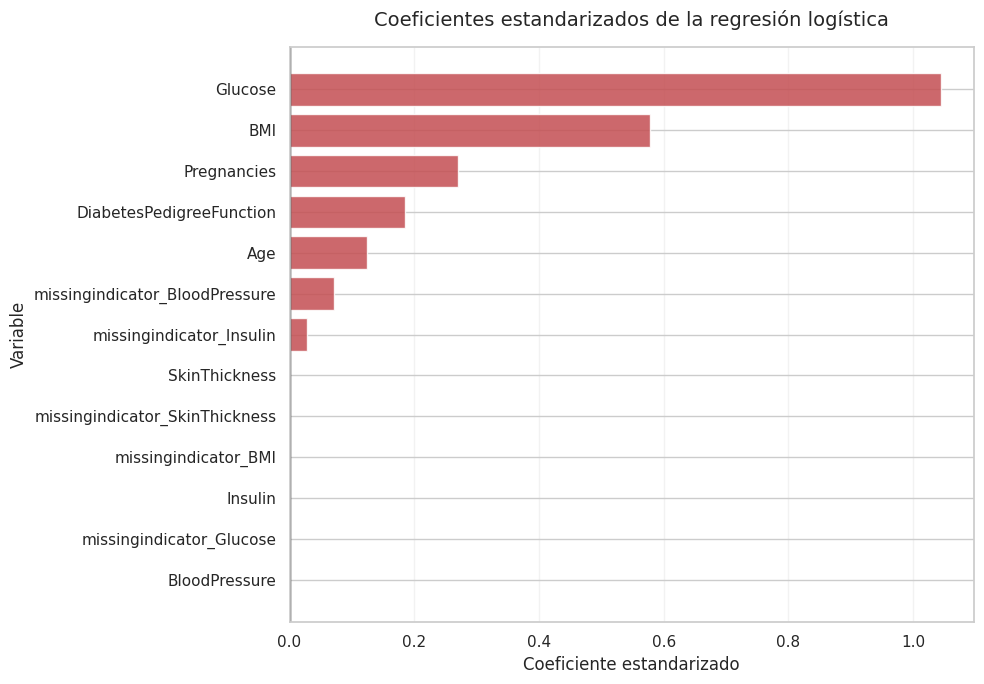

In [25]:
coefficient_plot_data = coefficient_results.sort_values(
    "coeficiente_estandarizado"
)

coefficient_colors = np.where(
    coefficient_plot_data[
        "coeficiente_estandarizado"
    ] >= 0,
    "#C44E52",
    "#4C72B0"
)

fig, ax = plt.subplots(
    figsize=(10, 7)
)

ax.barh(
    coefficient_plot_data["variable"],
    coefficient_plot_data[
        "coeficiente_estandarizado"
    ],
    color=coefficient_colors,
    alpha=0.85
)

ax.axvline(
    0,
    color="black",
    linewidth=1
)

ax.set_title(
    "Coeficientes estandarizados de la regresión logística",
    fontsize=14,
    pad=15
)

ax.set_xlabel(
    "Coeficiente estandarizado"
)

ax.set_ylabel(
    "Variable"
)

ax.grid(
    axis="x",
    alpha=0.25
)

plt.tight_layout()
plt.show()

### Interpretación de los coeficientes

La glucosa presentó el coeficiente estandarizado de mayor magnitud, seguida por el índice de masa corporal. Esto indica que, dentro del modelo ajustado, valores más elevados de estas variables son los que más incrementan la probabilidad estimada de pertenecer a la clase positiva.

El número de embarazos, la función de pedigrí de diabetes y la edad también mostraron asociaciones positivas, aunque de menor magnitud. En conjunto, estas variables aportan información adicional a la predicción una vez consideradas las demás características incluidas en el modelo.

Los indicadores de ausencia de presión arterial e insulina conservaron coeficientes positivos pequeños. Esto sugiere que el patrón de datos faltantes podría contener cierta información predictiva, aunque su contribución es considerablemente menor que la de la glucosa o el índice de masa corporal.

La regularización L1 redujo a cero los coeficientes de presión arterial, grosor de la piel, insulina y varios indicadores de ausencia. Esto no demuestra que dichas variables carezcan de relevancia clínica. Significa que, dentro de esta muestra y en presencia de las demás variables, el modelo no encontró suficiente contribución predictiva adicional para conservarlas.

Todos los coeficientes restantes fueron positivos. Sus magnitudes corresponden a variables previamente estandarizadas, por lo que permiten comparar su influencia relativa dentro del modelo, pero no representan efectos clínicos directos ni relaciones causales.

## Limitaciones

Este análisis presenta varias limitaciones que deben considerarse al interpretar sus resultados:

1. El conjunto de datos contiene únicamente 768 observaciones y el conjunto de prueba está compuesto por 154 registros. Por ello, algunas métricas presentan intervalos de confianza amplios.

2. La base procede de una población histórica y específica, por lo que los resultados no pueden generalizarse automáticamente a hombres, otros grupos de edad, otras poblaciones o contextos clínicos actuales.

3. Algunos valores iguales a cero fueron interpretados como mediciones ausentes porque no resultan clínicamente plausibles. Aunque esta decisión es consistente con el significado de las variables, no se dispone de información que permita conocer el mecanismo exacto que produjo cada ausencia.

4. La imputación mediante la mediana reduce la pérdida de observaciones, pero no reconstruye necesariamente el valor real que habría sido medido.

5. La selección, calibración y evaluación se realizaron sobre una sola base de datos. Aunque se utilizaron validación cruzada, predicciones fuera de pliegue y un conjunto de prueba independiente, todavía se requiere validación externa.

6. Los intervalos obtenidos mediante bootstrap representan la variabilidad dentro de esta muestra, pero no corrigen posibles sesgos de selección ni garantizan representatividad poblacional.

7. La importancia de las variables describe el funcionamiento predictivo del modelo. No permite establecer causalidad, emitir recomendaciones médicas ni sustituir una evaluación clínica.

## Conclusiones

Este proyecto evaluó diferentes estrategias para tratar mediciones ausentes codificadas como cero y comparó modelos de clasificación para estimar el riesgo de diabetes.

La estrategia seleccionada conservó todas las observaciones, reemplazó los ceros clínicamente imposibles por valores ausentes, realizó imputación mediante la mediana e incorporó indicadores de ausencia dentro de un pipeline. De esta manera se evitó eliminar más de la mitad de la base de datos y se redujo el riesgo de introducir sesgo de selección.

La regresión logística regularizada presentó un desempeño competitivo frente a Random Forest y XGBoost, con la ventaja adicional de ofrecer una estructura más sencilla e interpretable. Después de aplicar calibración sigmoide, el modelo obtuvo en el conjunto de prueba:

- ROC-AUC de 0,812.
- PR-AUC de 0,671.
- Brier score de 0,175.
- Log loss de 0,515.

Con el umbral principal de 0,45, el modelo alcanzó una sensibilidad de 0,556 y una especificidad de 0,790. Al reducir el umbral a 0,27, la sensibilidad aumentó a 0,852 y los falsos negativos disminuyeron de 24 a 8, aunque la especificidad se redujo a 0,670.

Este contraste demuestra que la elección del umbral no es solamente una decisión estadística: depende del costo asociado a los falsos positivos y falsos negativos. En un escenario de tamizaje podría priorizarse la sensibilidad, mientras que otros contextos podrían requerir un equilibrio diferente.

La glucosa y el índice de masa corporal fueron las variables con mayor influencia relativa en la regresión logística. No obstante, los resultados corresponden a un ejercicio educativo y exploratorio. El modelo no está validado para uso clínico ni debe interpretarse como una herramienta diagnóstica.